# Implementacion del modelo de FitzHugh-Nagumo

Codigo de ejemplo en python para implementar el modelo FHN

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

Grafica de Nullclines

In [50]:
# Definir las constantes globales
# eps = 0.01
# a = 0.1
# gam = 0.5
# I = 0.5

a = 0.7
b = 0.8
gam = 12.5
I = 0.5


# # Definir las funciones
# def F(v):
#     return v*(1-v)*(v+a)

# def rhsV(w, v, I, eps):
#     return (F(v) - w + I) / eps

# def rhsW(w, v, gam):
#     return v - gam * w

# Definir las funciones
def rhsV(w, v, I):
    return v - (v**3 / 3) - w + I

def rhsW(w, v, a, b, gam):
    return (v + a - b * w) / gam


## Grafica de la trayectoria Nullclines

In [51]:
# Definir los rangos y listas de valores
vv = np.linspace(-5, 5, 1000)
nullv = []
nullw = []

# Función auxiliar para encontrar un intervalo adecuado
def find_root(func, bracket, v):
    try:
        root = root_scalar(func, bracket=bracket, args=(v), method='brentq', xtol=1e-6)
        if root.converged:
            return root.root
        else:
            return np.nan
    except ValueError:
        return np.nan


# Evaluar los nullclines
for v in vv:
    nullv.append(find_root(lambda w, v: rhsV(w, v, I), [-1.5, 3], v))
    nullw.append(find_root(lambda w, v: rhsW(w, v, a, b, gam), [-1.5, 3], v))
    

# Convertir listas a arrays para facilitar la manipulación
nullv = np.array(nullv)
nullw = np.array(nullw)


In [52]:
# Constants for the method
dt = 0.1                  # delta time in ms
t = np.arange(0, 200, dt)   # time array in ms

Vsol = np.zeros(len(t))
Wsol = np.zeros(len(t))
Vsol[0] = np.array(0)  # Valor inicial de la solucion
Wsol[0] = np.array(0)  # Valor inicial de la solucion


for i in range(0, len(t) - 1):

    # Euler method
    Vsol[i+1]= Vsol[i] + rhsV(Wsol[i], Vsol[i], I)*dt   # first assumption
    Wsol[i+1]= Wsol[i] + rhsW(Wsol[i], Vsol[i], a, b, gam)*dt
    


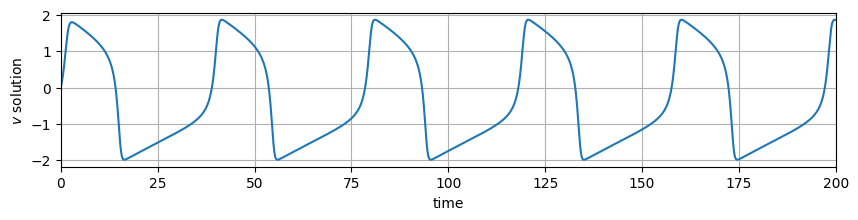

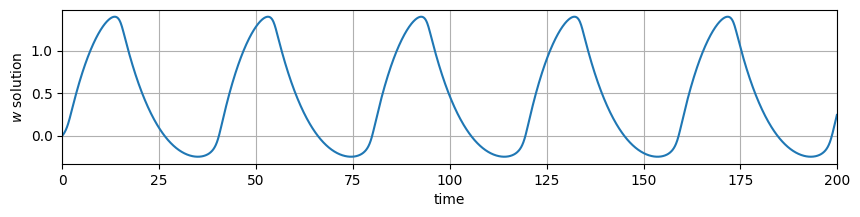

In [80]:
# Generar datos ficticios para T y Y
T = t
Y = np.zeros((len(t), 2))
Y[:, 0] = Vsol  # Datos ficticios para V, ajustar según sea necesario
Y[:, 1] = Wsol  # Datos ficticios para n, ajustar según sea necesario

plt.figure(figsize=(10,2))
plt.plot(T, Y[:,0])
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time')
plt.ylabel('$v$ solution')
plt.xlim([0, 200])
#plt.ylim([-80, 60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHN2_v.pdf", format="pdf", bbox_inches="tight")


# 
plt.figure(figsize=(10,2))
plt.plot(T, Y[:,1])

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time')
plt.ylabel('$w$ solution')
plt.xlim([0, 200])
#plt.ylim([0.3, 0.8])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHN2_w.pdf", format="pdf", bbox_inches="tight")


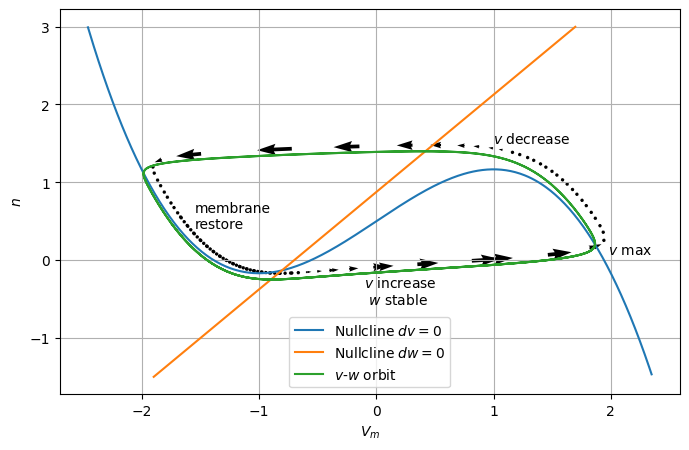

In [81]:
# Calcular las diferencias entre puntos para las flechas
dY = np.diff(Y[:,:], axis=0)

# posicion de los labels
p1 = 1970
p2 = 1990
p3 = 1300
p4 = 230

# Definir el rango de interés
ini = 1000
fin = 2000

# Graficar los nullclines y la trayectoria
plt.figure(figsize=(8, 5))

# Nullclines
plt.plot(vv, nullv, label='Nullcline $dv=0$')
plt.plot(vv, nullw, label='Nullcline $dw=0$')

# Trayectoria
plt.plot(Y[ini:fin, 0], Y[ini:fin, 1], label='$v$-$w$ orbit')

# Flechas para indicar la dirección del tiempo
skip = 10  # saltar puntos para no sobrecargar el gráfico con flechas
arrow_offset = 0.08  # desplazamiento de las flechas

plt.quiver(Y[ini:fin-1:skip, 0] + arrow_offset, Y[ini:fin-1:skip, 1] + arrow_offset, 
           dY[ini:fin:skip, 0], dY[ini:fin:skip, 1], 
           angles='xy', scale_units='xy', scale=.5, color='black')

# Añadir etiquetas
plt.text(Y[p1, 0], Y[p1, 1] - 5*arrow_offset, '$v$ increase\n $w$ stable', fontsize=10)
plt.text(Y[p2, 0] + 3*arrow_offset, Y[p2, 1] , '$v$ max', fontsize=10)
plt.text(Y[p3, 0], Y[p3, 1] + 2*arrow_offset, '$v$ decrease', fontsize=10)
plt.text(Y[p4, 0]+ arrow_offset, Y[p4, 1] + 2*arrow_offset, 'membrane\nrestore', fontsize=10)

plt.xlabel('$V_m$')
plt.ylabel('$n$')
#plt.axis([-80, 60, 0, 1])
plt.legend()
#plt.title('Nullclines and Trajectory with Direction')
plt.grid(True)

#plt.show()

plt.savefig("output/vw-nullclines.pdf", format="pdf", bbox_inches="tight")